In [105]:
pip install unstructured_inference

  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached annotated_doc-0.0.5-py3-none-any.whl.metadata (6.5 kB)
  Using cached markdown_it_py-4.2.0-py3-none-any.whl.metadata (7.4 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 25.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 62.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 52.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 72.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 846.4/846.4 kB 42.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.6/554.6 MB 52.9 MB/s  0:00:08m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 553.1/553.1 MB 55.1 MB/s  0:00:08m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 40.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━

In [108]:
import os
from langchain.chat_models import init_chat_model
from langchain_core.document_loaders import Blob
from langchain_ollama import ChatOllama
from langchain_community.document_loaders.parsers.txt import TextParser
from langchain_community.document_loaders import UnstructuredPDFLoader, UnstructuredExcelLoader
from typing import List, Dict, Any
from typing_extensions import TypedDict
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
from pathlib import Path
import json

In [99]:
def parse_file_to_text(file_path: str) -> str:

    ext = os.path.splitext(file_path)[1].lower()

    if ext == ".eml":
        blob = Blob.from_path(file_path, mime_type="message/rfc822")
        docs = TextParser().parse(blob)
    elif ext in [".txt", ".md", ".csv"]:
        blob = Blob.from_path(file_path, mime_type="text/plain")
        docs = TextParser().parse(blob)
    elif ext == ".pdf":
        loader = UnstructuredPDFLoader(file_path, mode="elements", strategy="fast")
        docs = loader.load()
    elif ext == ".xlsx":
        loader = UnstructuredExcelLoader(file_path, mode="elements")
        docs = loader.load()
    else:
        raise ValueError(f"Extension non supportée : {ext}")

    return "\n\n".join(doc.page_content for doc in docs)

In [ ]:
class AnalyzedEmail(BaseModel):
    subject: str = Field(description="Ex: Sujet principal du document")
    sender: str = Field(description="Ex: Expéditeur du document")
    date: str = Field(description="Date du document si précisée, sinon mettre 'N/A'")
    facts: List[str] = Field(description="Liste des informations ou données clés trouvées")
    action: str = Field(description="Actions prises, si applicable")

class AnalyzedPdf(BaseModel):
    title: str
    date: str
    facts: List[str]

class AnalyzedSpreadsheet(BaseModel):
    sheet_subject: str
    totals: Dict[str, Any]
    facts: List[str]

class AnalyzedText(BaseModel):
    title: str
    date: str
    facts: List[str]

SCHEMAS = {
    ".eml": AnalyzedEmail,
    ".pdf": AnalyzedPdf,
    ".xlsx": AnalyzedSpreadsheet,
    ".txt": AnalyzedText,
    ".md": AnalyzedText,
    ".csv": AnalyzedText,
}

class GraphState(TypedDict):
    folder: str
    pending: List[str]
    file_path: str
    file_text: str
    result: Any
    results: List[Dict[str, Any]]

In [101]:
llm = ChatOllama(
        model="llama3.1",
        temperature=0,
        base_url="http://localhost:11434"
        )

structured_llm = llm.with_structured_output(AnalyzedDocument)

In [102]:
def list_files_node(state: GraphState):
    root = Path(state["folder"])
    folders = [root, *sorted(path for path in root.rglob("*") if path.is_dir())]
    files = []
    for folder in folders:
        candidates = sorted(
            path for path in folder.iterdir()
            if path.is_file() and path.suffix.lower() != ".png"
        )
        if candidates:
            files.append(str(candidates[0]))
    return {"pending": files, "results": []}

def next_file_node(state: GraphState):
    pending = list(state["pending"])
    current = pending.pop(0)
    return {"file_path": current, "pending": pending}

def parse_file_node(state: GraphState):
    text = parse_file_to_text(state["file_path"])
    return {"file_text": text}

def analyze_content_node(state: GraphState):
    text = state["file_text"]
    result = structured_llm.invoke(
        f"Analyse le contenu suivant et remplis le schéma de données: {text}"
    )
    results = list(state.get("results") or [])
    results.append({"file_path": state["file_path"], "analysis": result})
    return {"result": result, "results": results}

def route_after_analysis(state: GraphState):
    if state["pending"]:
        return "next_file"
    return END

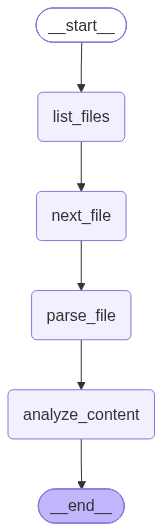

In [103]:
workflow = StateGraph(GraphState)
workflow.add_node("list_files", list_files_node)
workflow.add_node("next_file", next_file_node)
workflow.add_node("parse_file", parse_file_node)
workflow.add_node("analyze_content", analyze_content_node)
workflow.add_edge(START, "list_files")
workflow.add_edge("list_files", "next_file")
workflow.add_edge("next_file", "parse_file")
workflow.add_edge("parse_file", "analyze_content")
workflow.add_conditional_edges("analyze_content", route_after_analysis)
app = workflow.compile()
display(Image(app.get_graph().draw_mermaid_png()))

In [110]:
final_state = app.invoke({
    "folder": "starter/Projet360_NOVA_ETUDIANTS/",
    "pending": [],
    "file_path": "",
    "file_text": "",
    "result": None,
    "results": [],
})

for item in final_state["results"]:
    print(item)

{'file_path': 'starter/Projet360_NOVA_ETUDIANTS/MANIFEST.csv', 'analysis': AnalyzedDocument(file_type='01_Courriels', main_subject='Courriels', date='01_Courriels', extracted_facts=['01_Courriels/E01_Lancement_NOVA.eml', '01_Courriels/E02_Question_hebergement.eml', '01_Courriels/E03_Confirmation_Canada_Central.eml', '01_Courriels/E04_Corrections_accessibilite.eml', '01_Courriels/E05_Retard_integration.eml', '01_Courriels/E06_Transition_charge_projet.eml', '01_Courriels/E07_Facture_003_question.eml', '01_Courriels/E08_Correctif_journalisation.eml', '01_Courriels/E09_Rappel_mise_en_production.eml', '01_Courriels/E10_Fonction_mobile.eml', '01_Courriels/E11_Communication_statut.eml', '01_Courriels/E12_Resolution_integration.eml'], raw_data_summary={'01_Courriels/E01_Lancement_NOVA.eml': {'extension': '.eml', 'taille_octets': 735}, '01_Courriels/E02_Question_hebergement.eml': {'extension': '.eml', 'taille_octets': 32535}, '01_Courriels/E03_Confirmation_Canada_Central.eml': {'extension': '.e